In [2]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

0 0
0 1
0 1
0 2
0 2
1 2
2 2
3 2
2 2
2 3
2 3


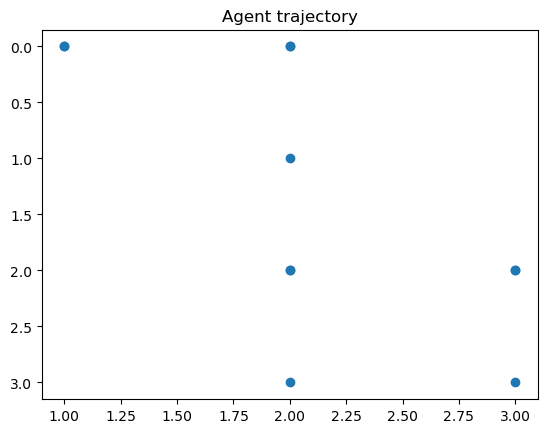

In [ ]:
from typing import Optional
import numpy as np
import gymnasium as gym
from collections import Counter

class RL_Bandit_Agent:
    def __init__(self):
        self.alpha = 0.2
        self.B = 2.0
        # self.Q_sa = np.zeros((2, 2))
        self.probs_a = 1
        self.probs_b = 0
        self.action_a = 1
        self.action_b = 0
        self.running_accuracy = None
        self.Q_sa = np.zeros((8, 8,4))
        self.accurate_count_list = []
        self.action = random.choice([0,1,2, 3])
        self.action_0 = 0
        self.action_1 = 1
        self.action_2 = 2
        self.action_3 = 3
        #self.reward = 0

    def softmax(self, Q_sa):
        Q_sa = Q_sa - np.max(Q_sa)
        exp_vals = np.exp(self.B * Q_sa)
        return exp_vals / np.sum(exp_vals)

    def take_action(self, x, y):
        #self.reward = reward
        probs = self.softmax(self.Q_sa[x, y])
        self.action = np.random.choice(len(probs), p=probs)

        #reward = 1 if action == outcome else 0
        #self.Q_sa[self.action] = self.Q_sa[self.action] + self.alpha * (reward - self.Q_sa[self.action])

        # self.accurate_count_list.append(reward)

        # self.running_accuracy = np.cumsum(self.accurate_count_list) / np.arange(
        #     1, len(self.accurate_count_list) + 1
        # )

        return self.action
    
    def update_Q(self, reward, x, y):
        self.Q_sa[x, y, self.action] = self.Q_sa[x, y, self.action] + self.alpha * (reward - self.Q_sa[x, y, self.action])
        #return self.Q_sa

class GridWorldEnv(gym.Env):
    def __init__(self, size: int = 4):
        # The size of the square grid (5x5 by default)
        self.size = size
        self.action = 0

        # Initialize positions - will be set randomly in reset()
        # Using -1,-1 as "uninitialized" state
        self._agent_location = np.array([-1, -1], dtype=np.int32)
        self._target_location = np.array([-1, -1], dtype=np.int32)
        self.dist = None
        self.prev_dist = None
        self.prev_location = None

        # Define what the agent can observe
        # Dict space gives us structured, human-readable observations
        self.observation_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(0, size - 1, shape=(2,), dtype=int),   # [x, y] coordinates
                "target": gym.spaces.Box(0, size - 1, shape=(2,), dtype=int),  # [x, y] coordinates
            }
        )

        # Define what actions are available (4 directions)
        self.action_space = gym.spaces.Discrete(4)

        # Map action numbers to actual movements on the grid
        # This makes the code more readable than using raw numbers
        self._action_to_direction = {
            0: np.array([0, 1]),   # Move right (column + 1)
            1: np.array([-1, 0]),  # Move up (row - 1)
            2: np.array([0, -1]),  # Move left (column - 1)
            3: np.array([1, 0]),   # Move down (row + 1)
        }

        self.hole_coords = {(1, 1), (3, 1), (3, 2)}

    def _get_obs(self):
        """Convert internal state to observation format.

        Returns:
            dict: Observation with agent and target positions
        """
        return {"agent": self._agent_location, "target": self._target_location}
    

    def _get_info(self):
        """Compute auxiliary information for debugging.

        Returns:
            dict: Info with distance between agent and target
        """
        return {
            "distance": np.linalg.norm(
                self._agent_location - self._target_location, ord=1
            )
        }
    

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        """Start a new episode.

        Args:
            seed: Random seed for reproducible episodes
            options: Additional configuration (unused in this example)

        Returns:
            tuple: (observation, info) for the initial state
        """
        # IMPORTANT: Must call this first to seed the random number generator
        super().reset(seed=seed)

        # Randomly place the agent anywhere on the grid
        self._agent_location = np.array([0, 0], dtype=np.int32)

        # Randomly place target, ensuring it's different from agent position
        self._target_location = np.array([3, 3], dtype=np.int32)
        # while np.array_equal(self._target_location, self._agent_location):
        #     self._target_location = self.np_random.integers(
        #         0, self.size, size=2, dtype=int
        #     )

        observation = self._get_obs()
        info = self._get_info()
        self.prev_location = self._agent_location
        self.prev_dist = np.abs(self._agent_location[0] - self._target_location[0] 
                                   +
                                   self._agent_location[1] - self._target_location[1])

        return observation, info
    
    
    def step(self, action):
        """Execute one timestep within the environment.

        Args:
            action: The action to take (0-3 for directions)

        Returns:
            tuple: (observation, reward, terminated, truncated, info)
        """
        # Map the discrete action (0-3) to a movement direction
        direction = self._action_to_direction[action]

        # Update agent position, ensuring it stays within grid bounds
        # np.clip prevents the agent from walking off the edge
        self.prev_location = self._agent_location.copy()

        self._agent_location = np.clip(
            self._agent_location + direction, 0, self.size - 1
        )

        self.dist = (np.abs(self._agent_location[0] - self._target_location[0]) +
                                   np.abs(self._agent_location[1] - self._target_location[1]))

        # Check if agent reached the target
        terminated = np.array_equal(self._agent_location, self._target_location)

        # We don't use truncation in this simple environment
        # (could add a step limit here if desired)
        truncated = False

        # Simple reward structure: +1 for reaching target, 0 otherwise
        # Alternative: could give small negative rewards for each step to encourage efficiency
        observation = self._get_obs()
        info = self._get_info()

        location_as_tuple = tuple(self._agent_location)
        if location_as_tuple in self.hole_coords:
            reward = -5
        elif self.dist < self.prev_dist:
            reward = 1
        elif self.dist == self.prev_dist:
            reward = 0
        else:
            reward = -1
        #reward = 1 if self.dist < self.prev_dist else 0
        #reward = 1 if self._agent_location == self._target_location else 0

        self.prev_dist = self.dist

        return observation, reward, terminated, truncated, info


env = GridWorldEnv()
agent = RL_Bandit_Agent()
env.reset()
terminated = False
path = []
for step in range(0, 500):
    if terminated == False:
        action = agent.take_action(env._agent_location[0], env._agent_location[1])
        observation, reward, terminated, truncated, info = env.step(action)
        agent.update_Q(reward, env.prev_location[0], env.prev_location[1])
        print(env.prev_location[0], env.prev_location[1])
        path.append(tuple(env._agent_location))


path = np.array(path)

plt.scatter(path[:,1], path[:,0])
plt.gca().invert_yaxis()
plt.title("Agent trajectory")
plt.show()

In [43]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

env = GridWorldEnv()
agent = RL_Bandit_Agent()
env.reset()
terminated = False
steps = [tuple(env._agent_location)]
for _ in range(100):
    if terminated:
        break
    action = agent.take_action(env._agent_location[0], env._agent_location[1])
    observation, reward, terminated, truncated, info = env.step(action)
    agent.update_Q(reward, env.prev_location[0], env.prev_location[1])
    steps.append(tuple(env._agent_location))

fig, ax = plt.subplots(figsize=(5, 5))
target = tuple(env._target_location)
holes = env.hole_coords

def animate(i):
    ax.clear()
    ax.set_xlim(-0.5, env.size - 0.5)
    ax.set_ylim(-0.5, env.size - 0.5)
    ax.set_xticks(range(env.size))
    ax.set_yticks(range(env.size))
    ax.grid(True)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(f'Step {i}')

    # Holes
    for (r, c) in holes:
        ax.plot(c, r, 's', color='red', markersize=20)
    # Target
    ax.plot(target[1], target[0], '*', color='green', markersize=20)
    # Agent
    ax.plot(steps[i][1], steps[i][0], 's', color='blue', markersize=20)

anim = FuncAnimation(fig, animate, frames=len(steps), interval=200)
plt.close()
HTML(anim.to_jshtml())
